In [27]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "figure.facecolor": "white",
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "font.size": 10,
})
from MDAnalysis import transformations as trans
import nglview as nv
import warnings
warnings.filterwarnings("ignore")

from _helper_functions import *


In [36]:
data = './data.lmp'
topo = './result_atoms.data'
traj = './result_atoms.lammpstrj'

type_to_element = get_type_element_map(data) # get type to element mapping from original data file
type_to_element

resnames = ['wall']*2+['H2O']*2000 # resname per-residue lists

u = Trajectory.read_lammps_dump(topo, traj, type_to_element, resnames, dt=1)

workflow = [move_origin_to_corner,
            trans.wrap(u.atoms,compound='residues'),
            ]
u.trajectory.add_transformations(*workflow)

view = nv.show_mdanalysis(u)
view.clear_representations()
view.add_representation(selection='H2O',repr_type='licorice',radius='.5',opacity=1)
view.add_representation(selection='wall',repr_type='ball+stick',radius='.5',opacity=1)
view.add_unitcell()
#view.camera = 'orthographic'
view.control.spin([1,0,0],-np.pi/2.)

box dimensions: [ 33.6582  33.313  100.      90.      90.      90.    ]
frame num: 1


In [37]:
view

NGLWidget()

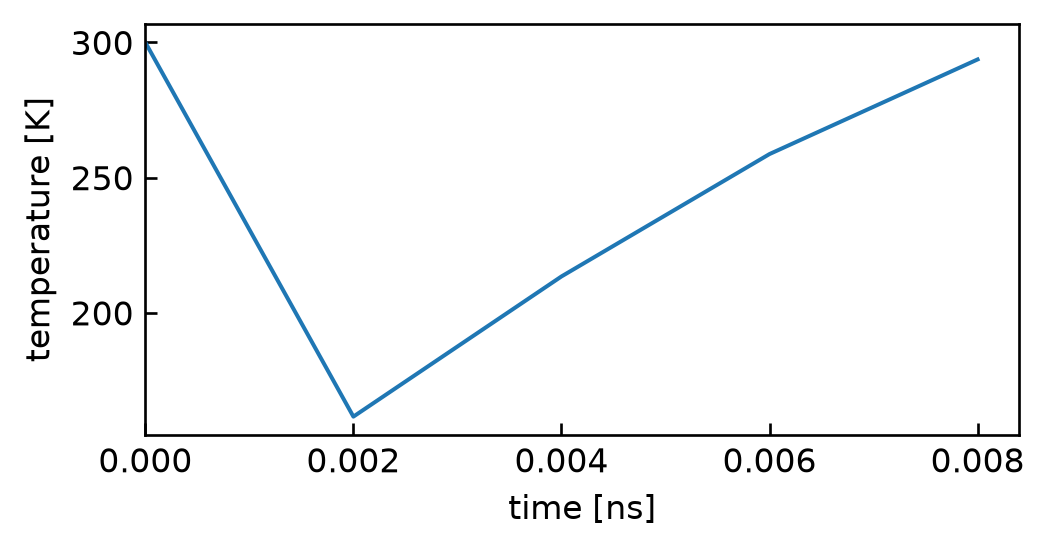

In [30]:
# temperature of fluid (thermo → log.lammps)

fig, ax = plt.subplots(figsize=(4.5, 2.4))

data = read_result_thermo("log.lammps")
t0 = data["time"].iloc[0]
x = (data["time"] - t0) / 1e6  # fs → ns
ax.plot(x, data["temp"], "-")

ax.set_xlabel("time [ns]")
ax.set_ylabel("temperature [K]")
ax.set_xlim(0, None)
ax.tick_params(direction="in")

fig.tight_layout()
plt.show()


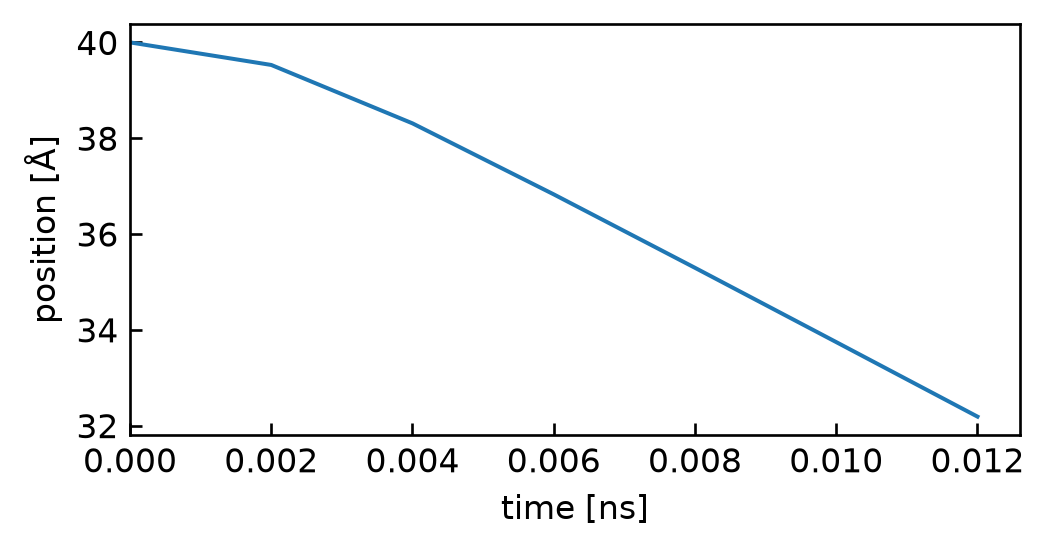

In [39]:
# position of top wall (thermo → log.lammps)

fig, ax = plt.subplots(figsize=(4.5, 2.4))

data = read_result_thermo("log.lammps")
t0 = data["time"].iloc[0]
x = (data["time"] - t0) / 1e6  # fs → ns
ax.plot(x, data["upper_cmz"], "-") 

ax.set_xlabel("time [ns]")
ax.set_ylabel("position [Å]")
ax.set_xlim(0, None)
ax.tick_params(direction="in")

fig.tight_layout()
plt.show()


* We can see the system reaches the equlibrium state quickly.

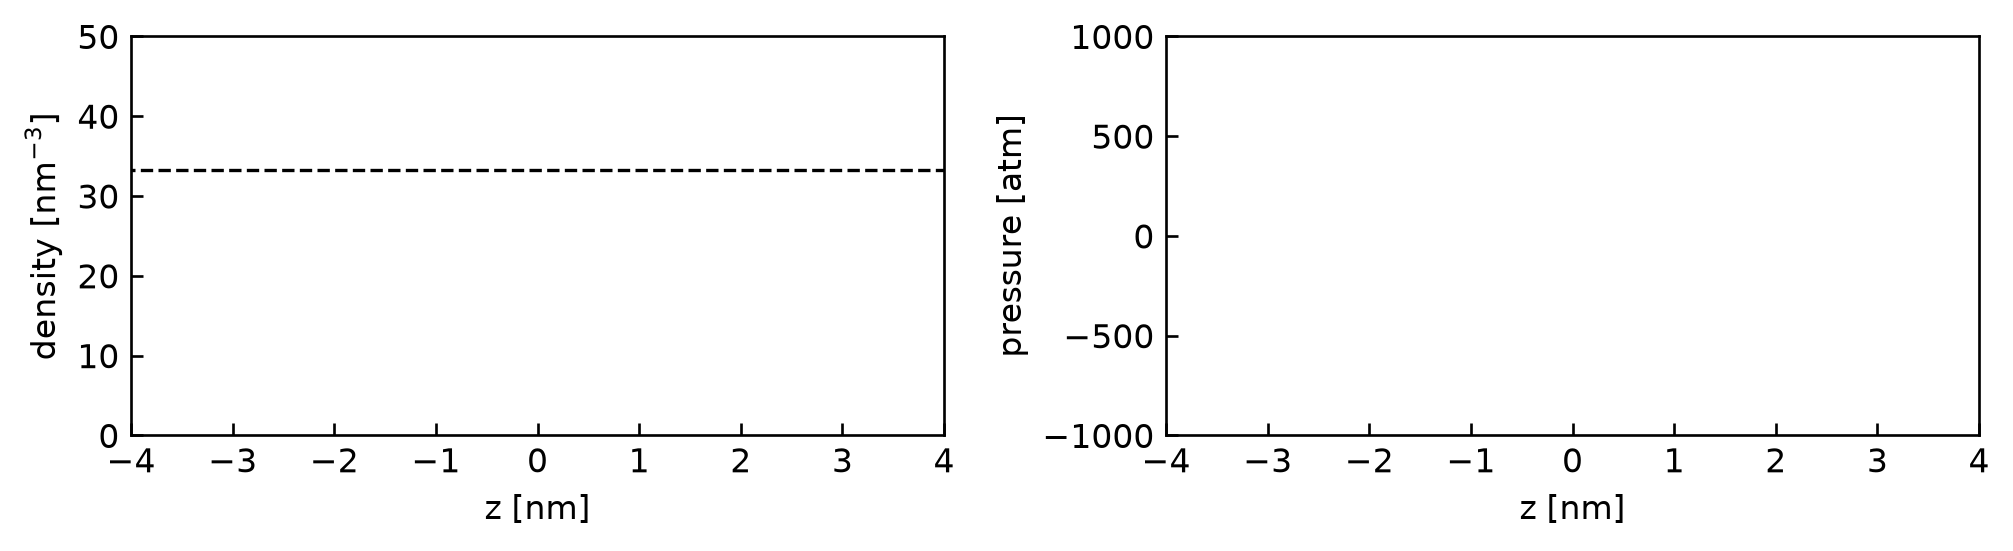

In [32]:
# density of fluid and local pressure (ave/chunk → result_profile_stress.log)

names = ["id", "z", "n", "sxx", "syy", "szz", "den"]
stress = pd.read_csv(
    "result_profile_stress.log",
    header=None,
    names=names,
    sep=r"\s+",
    skiprows=4,
)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(8.5, 2.4))

x = stress["z"] / 10  # Å → nm
ax0.plot(x, stress["den"] / 3 * 1e3, color="tab:blue")
ax0.plot((-10, 10), (33.3, 33.3), "k--", lw=1)
ax0.set_xlabel("z [nm]")
ax0.set_ylabel(r"density [nm$^{-3}$]")
ax0.set_xlim(-4, 4)
ax0.set_ylim(0, 50)
ax0.tick_params(direction="in")

press = -(stress["sxx"] + stress["syy"] + stress["szz"]) / 3 * stress["den"]
ax1.plot(x, press, color="tab:blue")
ax1.set_xlabel("z [nm]")
ax1.set_ylabel("pressure [atm]")
ax1.set_xlim(-4, 4)
ax1.set_ylim(-1e3, 1e3)
ax1.tick_params(direction="in")

fig.tight_layout()
plt.show()


* The bulk density of fluid is $\sim 33$ nm$^{-3}$, closing the bulk density of SPC/E water at $300$ K and $1$ atm, suggesting the pressure control works well.
* The local pressure profile shows significantly osillations, but we can see the pressure of bulk fluid fluctuates around $\sim 1$ atm.